In [ ]:
import kagglehub

# Downloading latest version
path = kagglehub.dataset_download("crawford/gene-expression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gene-expression' dataset.
Path to dataset files: /kaggle/input/gene-expression


In [ ]:
# Checking the files in path
import os

print(os.listdir(path))


['.nfs00000000372c6c9800000296', 'data_set_ALL_AML_independent.csv', 'data_set_ALL_AML_train.csv', 'actual.csv']


In [ ]:
# Test and train set is already grouped inside the file
# defining test and train path

import pandas as pd

train_path = path + "/data_set_ALL_AML_train.csv"
test_path = path + "/data_set_ALL_AML_independent.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

print(train_df.head())

Train Shape: (7129, 78)
Test Shape: (7129, 70)
                      Gene Description Gene Accession Number    1 call    2  \
0  AFFX-BioB-5_at (endogenous control)        AFFX-BioB-5_at -214    A -139   
1  AFFX-BioB-M_at (endogenous control)        AFFX-BioB-M_at -153    A  -73   
2  AFFX-BioB-3_at (endogenous control)        AFFX-BioB-3_at  -58    A   -1   
3  AFFX-BioC-5_at (endogenous control)        AFFX-BioC-5_at   88    A  283   
4  AFFX-BioC-3_at (endogenous control)        AFFX-BioC-3_at -295    A -264   

  call.1    3 call.2    4 call.3  ...   29 call.33   30 call.34   31 call.35  \
0      A  -76      A -135      A  ...   15       A -318       A  -32       A   
1      A  -49      A -114      A  ... -114       A -192       A  -49       A   
2      A -307      A  265      A  ...    2       A  -95       A   49       A   
3      A  309      A   12      A  ...  193       A  312       A  230       P   
4      A -376      A -419      A  ...  -51       A -139       A -367       A  

In [ ]:
train_df = train_df.loc[:, ~train_df.columns.str.contains('call')]
test_df = test_df.loc[:, ~test_df.columns.str.contains('call')]

print(train_df.shape)
print(test_df.shape)

(7129, 40)
(7129, 36)


In [ ]:
print(train_df.columns[:10])

Index(['Gene Description', 'Gene Accession Number', '1', '2', '3', '4', '5',
       '6', '7', '8'],
      dtype='object')


In [ ]:
# Remove Gene Description only if exists
if 'Gene Description' in train_df.columns:
    train_df = train_df.drop(columns=['Gene Description'])

if 'Gene Description' in test_df.columns:
    test_df = test_df.drop(columns=['Gene Description'])

In [ ]:
train_df = train_df.set_index('Gene Accession Number')
test_df = test_df.set_index('Gene Accession Number')

In [ ]:
train_df = train_df.T
test_df = test_df.T

print(train_df.shape)
print(test_df.shape)

(38, 7129)
(34, 7129)


In [ ]:
# defining the actual path and using the csv file here.
# Combine train + independent datasets
import pandas as pd

full_df = pd.concat([train_df, test_df], axis=0)

print(full_df.shape)
actual_path = path + "/actual.csv"

actual_df = pd.read_csv(actual_path)

print(actual_df.head())
print(actual_df.columns)

(72, 7129)
   patient cancer
0        1    ALL
1        2    ALL
2        3    ALL
3        4    ALL
4        5    ALL
Index(['patient', 'cancer'], dtype='object')


In [ ]:
import numpy as np

# Label column creation
y = actual_df['cancer']

# Label encoding
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(np.unique(y))

[0 1]


In [ ]:
X = train_df.copy()

print(X.shape)

(38, 7129)


In [ ]:
print(actual_df.shape)
print(actual_df.head(50))

(72, 2)
    patient cancer
0         1    ALL
1         2    ALL
2         3    ALL
3         4    ALL
4         5    ALL
5         6    ALL
6         7    ALL
7         8    ALL
8         9    ALL
9        10    ALL
10       11    ALL
11       12    ALL
12       13    ALL
13       14    ALL
14       15    ALL
15       16    ALL
16       17    ALL
17       18    ALL
18       19    ALL
19       20    ALL
20       21    ALL
21       22    ALL
22       23    ALL
23       24    ALL
24       25    ALL
25       26    ALL
26       27    ALL
27       28    AML
28       29    AML
29       30    AML
30       31    AML
31       32    AML
32       33    AML
33       34    AML
34       35    AML
35       36    AML
36       37    AML
37       38    AML
38       39    ALL
39       40    ALL
40       41    ALL
41       42    ALL
42       43    ALL
43       44    ALL
44       45    ALL
45       46    ALL
46       47    ALL
47       48    ALL
48       49    ALL
49       50    AML


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(len(y))
print(np.unique(y))

72
[0 1]


In [ ]:
from sklearn.model_selection import train_test_split

X = full_df.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(57, 7129)
(15, 7129)


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=100)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print(X_train_selected.shape)
print(X_test_selected.shape)

(57, 100)
(15, 100)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Random Forest': RandomForestClassifier(class_weight='balanced'),
    'SVM': SVC(probability=True, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),
    'KNN': KNeighborsClassifier()
}

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

results = []
roc_data = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

    roc_data[name] = y_prob

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=['Model','Accuracy','Precision','Recall','F1','ROC-AUC']
)

print(results_df)

                 Model  Accuracy  Precision  Recall        F1  ROC-AUC
0        Random Forest  0.733333   0.666667     0.4  0.500000     0.70
1                  SVM  0.733333   0.600000     0.6  0.600000     0.88
2  Logistic Regression  0.933333   1.000000     0.8  0.888889     0.94
3                  KNN  0.733333   0.666667     0.4  0.500000     0.79


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

Cross Validation Scores: [0.8        0.73333333 0.78571429 0.71428571 1.        ]
Mean Accuracy: 0.8066666666666666
Std: 0.1017577934414711


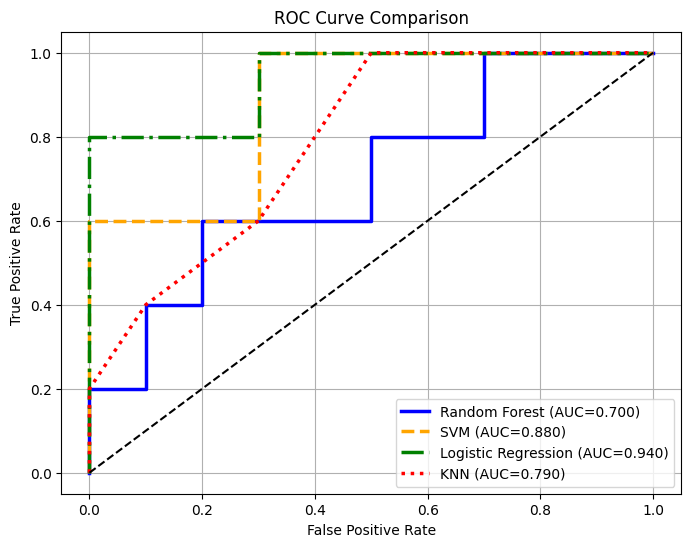

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

styles = {
    'Random Forest': ('blue', '-'),
    'SVM': ('orange', '--'),
    'Logistic Regression': ('green', '-.'),
    'KNN': ('red', ':')
}

for name, probs in roc_data.items():

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)

    color, style = styles[name]

    plt.plot(
        fpr,
        tpr,
        linestyle=style,
        linewidth=2.5,
        color=color,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot([0,1],[0,1], linestyle='--', color='black')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()

plt.show()

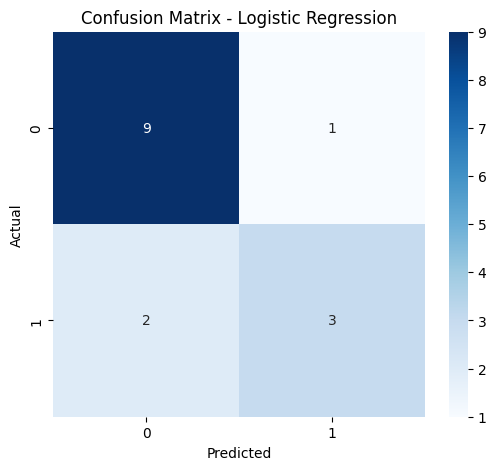

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

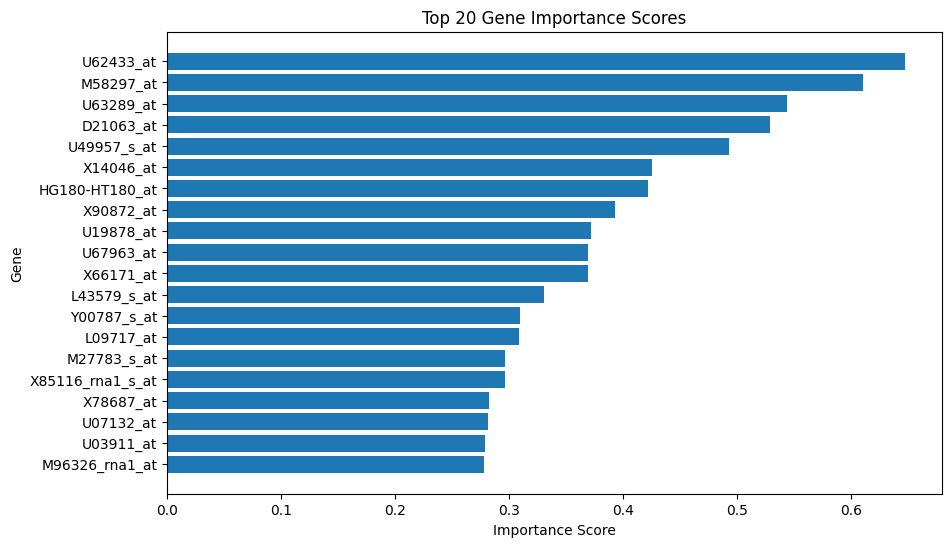

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

# Importance
importance = np.abs(lr.coef_[0])

# Get selected feature indices
selected_indices = selector.get_support(indices=True)

# Get gene names
gene_names = X.columns[selected_indices]

# Create dataframe
importance_df = pd.DataFrame({
    'Gene': gene_names,
    'Importance': importance
})

# Sort top genes
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top20 = importance_df.head(20)

# Plot
plt.figure(figsize=(10,6))

plt.barh(top20['Gene'], top20['Importance'])

plt.xlabel('Importance Score')
plt.ylabel('Gene')
plt.title('Top 20 Gene Importance Scores')

plt.gca().invert_yaxis()

plt.show()

CV Scores: [0.8        0.73333333 0.78571429 0.71428571 1.        ]
Mean: 0.8066666666666666
Std: 0.1017577934414711


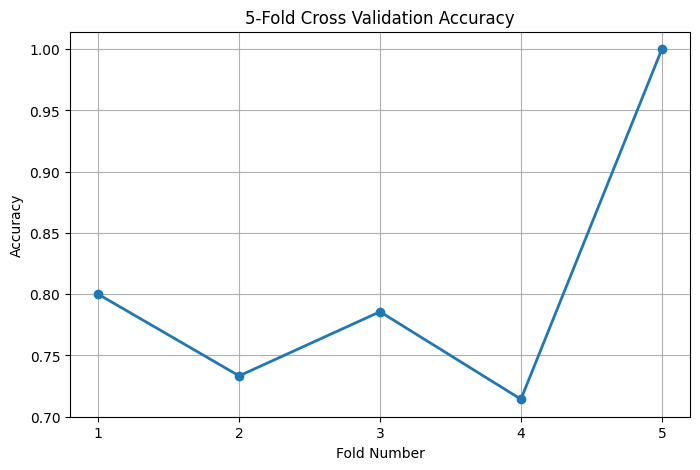

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    range(1,6),
    scores,
    marker='o',
    linewidth=2
)

plt.xticks(range(1,6))
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross Validation Accuracy')
plt.grid()

plt.show()